In [45]:
# Imports
import torch
import torchvision
import transformers
import sys
from transformers import AutoProcessor
from transformers import CLIPModel
import pandas as pd
import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# Record versions
print("Python version: ", sys.version)
print("PyTorch version: ", torch.__version__)
print("torchvision version: ", torchvision.__version__)
print("Transformers version: ", transformers.__version__)

x = torch.rand(5, 3)
print(x)

processor = AutoProcessor.from_pretrained("openai/clip-vit-large-patch14")
print(processor)

Python version:  3.10.11 (v3.10.11:7d4cc5aa85, Apr  4 2023, 19:05:19) [Clang 13.0.0 (clang-1300.0.29.30)]
PyTorch version:  2.13.0
torchvision version:  0.28.0
Transformers version:  5.15.1
tensor([[0.7702, 0.8611, 0.2495],
        [0.0195, 0.1462, 0.4216],
        [0.6590, 0.9754, 0.2268],
        [0.2172, 0.4495, 0.3892],
        [0.2335, 0.2720, 0.5405]])
CLIPProcessor:
- image_processor: CLIPImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "CLIPImageProcessor",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}

- tokenizer: CLIPTokenizer(name_or_path='openai/clip-vit-large-patch14', vocab_size=49408, model_max_length=77, padding

Check that CLIP's resize target matches the crop size, so that the images don't lose any of their edges after they're made square.

In [12]:
processor.image_processor.size

SizeDict(height=None, width=None, longest_edge=None, shortest_edge=224, max_height=None, max_width=None)

In [13]:
if torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

Load CLIP model

In [ ]:
model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
model.to(device)
model.eval()

print(model.config.projection_dim)
print(next(model.parameters()).device)

Loading weights: 100%|██████████| 590/590 [00:00<00:00, 7603.40it/s]


768
mps:0


Test on 8 products.
Pick 8 products across a range:
- most extreme ratios
- some low res
- some random

In [ ]:
df = pd.read_csv('data/train_with_target.csv', usecols=['external_code', 'image_path', 'category', 'color', 'fabric'])

df_img = pd.read_csv('data/image_meta.csv', usecols=['external_code', 'w', 'h', 'low_res'])

path = kagglehub.dataset_download("konradb/visuelle-complete-dataset")
image_root = Path(path) / 'images'

pick_sample = df.merge(df_img, on='external_code', how='inner')

pick_sample['ratio'] = pick_sample['w'] / pick_sample['h']


# Two samples with the most extreme ratios
max_sample = pick_sample.loc[pick_sample['ratio'].idxmax(), 'external_code']
min_sample = pick_sample.loc[pick_sample['ratio'].idxmin(), 'external_code']

# Two samples that are low res
lowres_sample = pick_sample[pick_sample['low_res'] == True].head(2)['external_code'].tolist()

# Four random ones
random_sample = pick_sample.sample(4, random_state=7)['external_code'].tolist()

collected_sample = [max_sample, min_sample] + lowres_sample + random_sample
collected_sample = list(dict.fromkeys(collected_sample))

trial_df = df[df['external_code'].isin(collected_sample)].copy()

print(trial_df.merge(df_img, on='external_code')[
    ['external_code', 'category', 'w', 'h', 'low_res']
])

   external_code       category    w    h  low_res
0            450      patterned  304  401    False
1           1078       culottes  202  180     True
2           1215       culottes   58  160     True
3           1733    long sleeve  516  476    False
4           2513  solid colours  594  898    False
5           2691       culottes   27  112     True
6           4287      patterned  653  159    False
7           4452  short sleeves  890  804    False


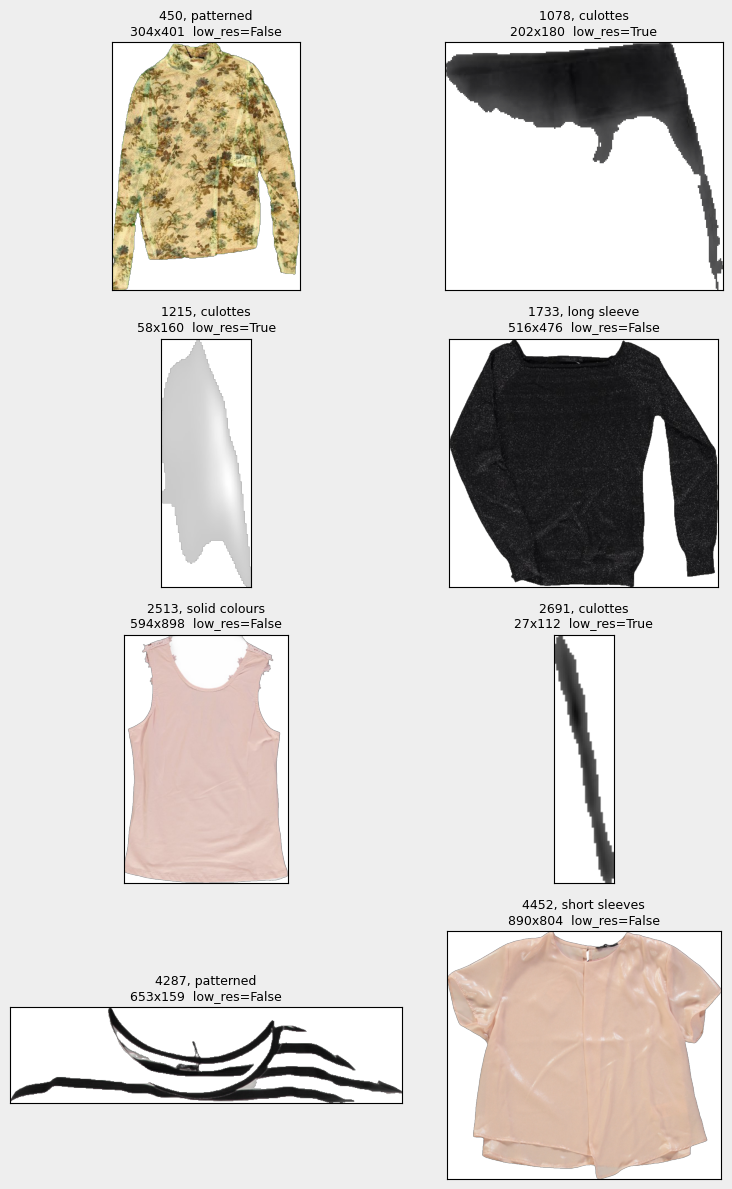

In [ ]:
# print matplot lib grid with the images of the 8 products 
# to visually check before going further

display_df = trial_df.merge(df_img, on='external_code').reset_index(drop=True)

fig, axes = plt.subplots(4, 2, figsize=(8, 12))
fig.patch.set_facecolor('#EEE')

for ax, row in zip(axes.ravel(), display_df.itertuples()):
    img = Image.open(image_root / row.image_path)
    assert img.size == (row.w, row.h)          # meta agrees with disk
    ax.imshow(img)
    ax.set_title(
        f"{row.external_code}, {row.category}\n"
        f"{row.w}x{row.h}  low_res={row.low_res}",
        fontsize=9,
    )
    ax.set_xticks([]); ax.set_yticks([])

fig.tight_layout()
plt.show()